### Passo 1: Importando as bibliotecas necessárias

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

### Passo 2: Preparando o dataset

In [ ]:
# Carrega os dados do CSV. Delimiter=',' indica que as colunas são separadas por vírgula.
# skiprows=2 para pular as duas linhas de cabeçalho/comentário.
dataset = np.loadtxt("tumores.csv", delimiter=',', skiprows=2)

# Separa as colunas de características (features) e a coluna de rótulos (labels)
# X_train recebe todas as linhas, mas apenas as duas primeiras colunas (índice 0 e 1)
X_train = dataset[:, :2]

# y_train recebe todas as linhas, mas apenas a última coluna (índice 2)
# .astype(int) para garantir que as classes sejam tratadas como inteiro
y_train = dataset[:, 2].astype(int)

print("Amostra das características (X_train):")
print(X_train[:5])
print("\nAmostra dos rótulos (y_train):")
print(y_train[:5])

Amostra das características (X_train):
[[1.9 2.5]
 [3.  3.9]
 [3.5 2.9]
 [2.2 2.2]
 [4.  4.5]]

Amostra dos rótulos (y_train):
[0 0 0 0 0]


### Passo 3: Visualizando os dados de treinamento
Antes de aplicar qualquer algoritmo, é sempre uma boa ideia visualizar nossos dados para entender sua distribuição.

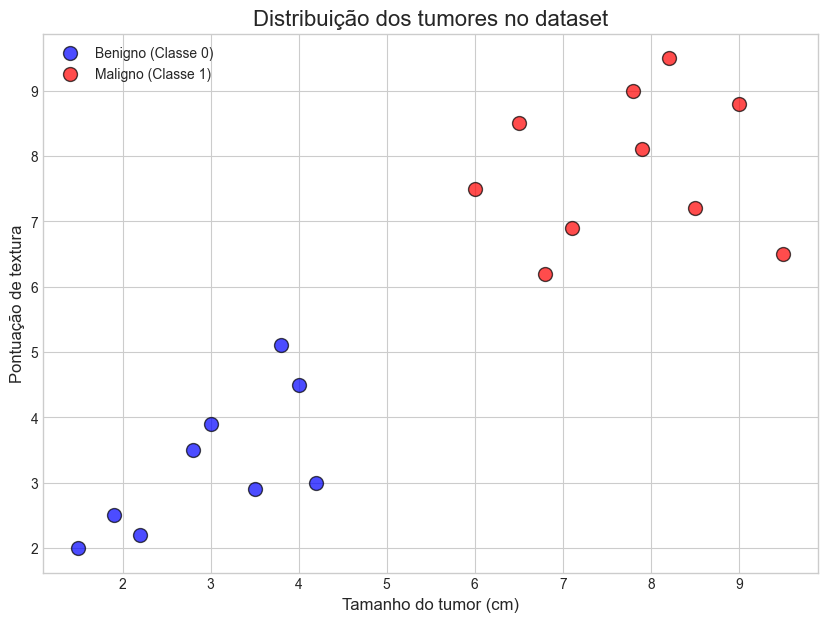

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
flg, ax = plt.subplots(figsize=(10,7))

# Plota os pontos Benignos (Classe 0)
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
           c='blue', s=100, edgecolors='k', alpha=0.7, label='Benigno (Classe 0)')

# Plota os pontos Malignos (Classe 1)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c='red', s=100, edgecolors='k', alpha=0.7, label='Maligno (Classe 1)')


ax.set_title('Distribuição dos tumores no dataset', fontsize=16)
ax.set_xlabel('Tamanho do tumor (cm)', fontsize=12)
ax.set_ylabel('Pontuação de textura', fontsize=12)
ax.legend()
plt.show()

### Passo 4: Implementando as funções do algoritmo KNN
Agora, vamos definir as três funções principais do nosso algoritmo KNN: uma para calcular a distância, outra para encontrar os vizinhos e a última para fazer a predição baseada na votação.

In [ ]:
def calcular_distancia_euclidiana(ponto1, ponto2):
    """Calcula a distância euclidiana entre dois pontos."""
    return np.sqrt(np.sum((ponto1 - ponto2)**2))

def encontrar_vizinhos(X_train, y_train, ponto_teste, k):
    """Encontra os k vizinhos mais próximos de um ponto de teste."""
    distancias = []
    for i, ponto_treino in enumerate(X_train):
        dist = calcular_distancia_euclidiana(ponto_treino, ponto_teste)
        distancias.append((dist, y_train[i]))

    # Ordena a lista de distâncias em ordem crescente
    distancias.sort(key=lambda x: x[0])

    # Retorna os k vizinhos mais próximos (seus rótulos)
    vizinhos = [distancia[1] for distancia in distancias[:k]]
    return vizinhos